# HCMST Project — Final Figures

This notebook creates the final presentation-ready figures from saved outputs.

It does not redo the analysis. It only loads cleaned result tables and exports polished visuals for slides.

In [5]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

In [6]:
profile_b = pd.read_csv(OUTPUT_TABLES / "cluster_profile_kmeans_without_gender.csv")
profile_h = pd.read_csv(OUTPUT_TABLES / "cluster_profile_hierarchical.csv")
model_results = pd.read_csv(OUTPUT_TABLES / "model_comparison_results.csv")
coef_df = pd.read_csv(OUTPUT_TABLES / "logistic_regression_coefficients.csv")

print(profile_b.shape)
print(profile_h.shape)
print(model_results.shape)
print(coef_df.shape)

(6, 8)
(6, 8)
(5, 6)
(60, 3)


## Figure 1 — Preferred K-Means Cluster Profile

This figure summarizes the preferred clustering solution: K-Means without gender.

In [7]:
cluster_plot = profile_b.copy()

if "cluster_b" in cluster_plot.columns:
    cluster_plot = cluster_plot.rename(columns={"cluster_b": "cluster"})

cluster_plot

,cluster,w1_ppage,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score,cluster_size_%
0,0,41.35,0.48,1.00,0.0,6.58,4.46,8.9
1,1,41.06,1.00,0.00,0.0,15.48,4.66,28.0
2,2,37.46,0.00,0.00,0.0,6.59,4.37,16.2
3,3,45.34,0.34,0.32,1.0,11.99,4.44,7.6
4,4,48.07,0.89,0.02,0.0,20.62,2.55,5.6
5,5,65.30,0.98,0.00,0.0,39.80,4.73,33.6


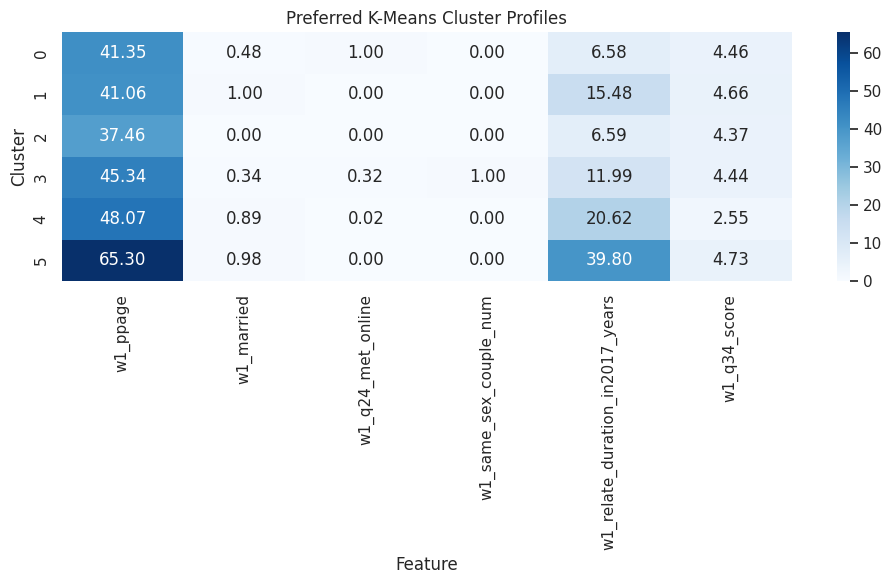

In [8]:
plot_cols = [
    "w1_ppage",
    "w1_married",
    "w1_q24_met_online",
    "w1_same_sex_couple_num",
    "w1_relate_duration_in2017_years",
    "w1_q34_score"
]

cluster_plot_indexed = cluster_plot.set_index(cluster_plot.columns[0])

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_plot_indexed[plot_cols],
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Preferred K-Means Cluster Profiles")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "final_cluster_profile_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 2 — Cluster Sizes

This figure shows how large each preferred K-Means cluster is.

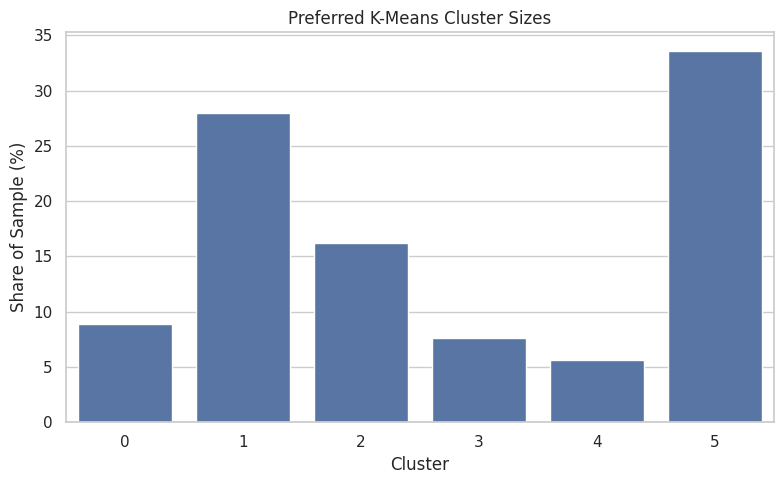

In [9]:
size_col = "cluster_size_%"

plt.figure(figsize=(8, 5))
sns.barplot(
    data=profile_b,
    x=profile_b.columns[0],
    y=size_col
)

plt.title("Preferred K-Means Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Share of Sample (%)")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "final_cluster_sizes.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 3 — Model Comparison

This figure compares predictive performance across logistic regression models.

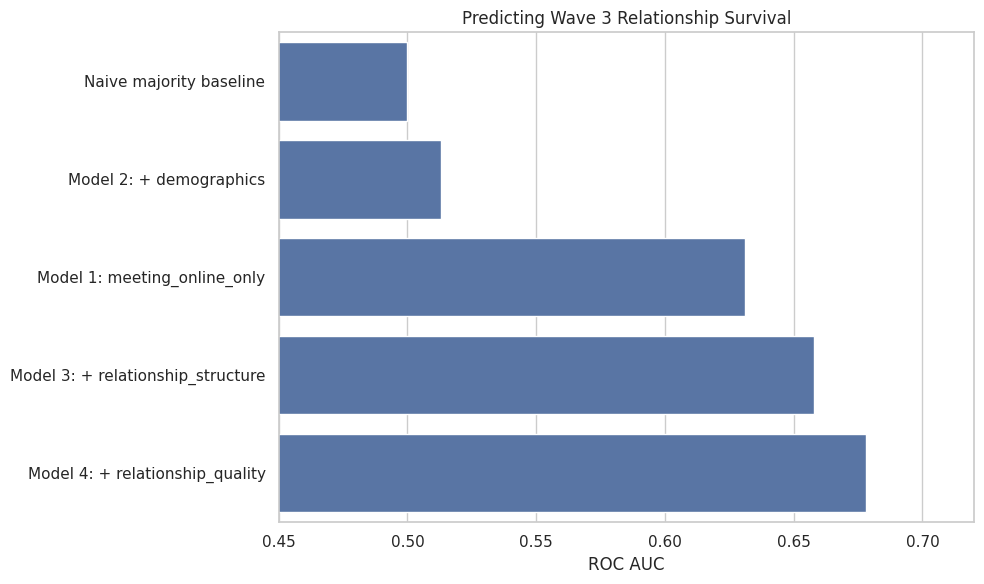

In [10]:
plot_df = model_results.sort_values("roc_auc", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="roc_auc",
    y="model"
)

plt.title("Predicting Wave 3 Relationship Survival")
plt.xlabel("ROC AUC")
plt.ylabel("")
plt.xlim(0.45, 0.72)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "final_model_comparison_roc_auc.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 4 — Top Logistic Regression Coefficients

This figure shows the strongest predictors from the final logistic regression model.

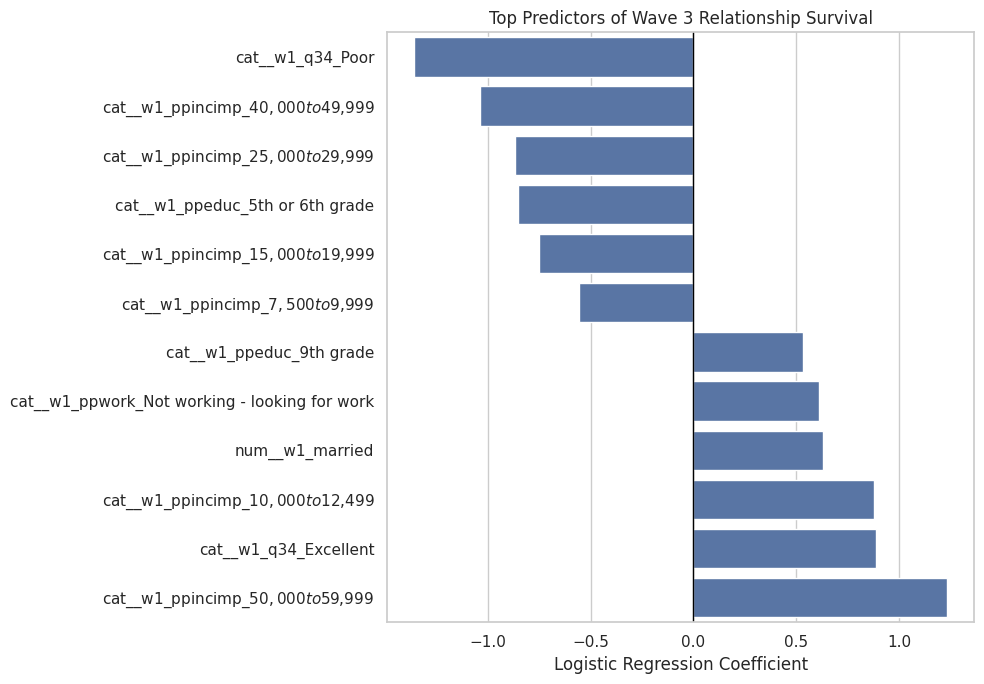

In [11]:
top_coef = coef_df.sort_values("abs_coefficient", ascending=False).head(12)
top_coef = top_coef.sort_values("coefficient")

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_coef,
    x="coefficient",
    y="feature"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Top Predictors of Wave 3 Relationship Survival")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "final_top_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 5 — K-Means vs Hierarchical Cluster Comparison

This figure compares cluster size distributions between the preferred K-Means solution and hierarchical clustering.

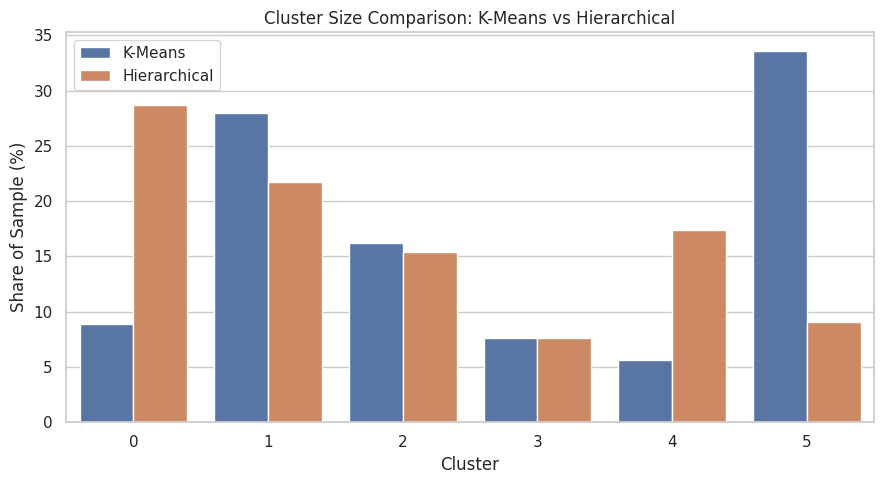

In [12]:
compare_sizes = pd.DataFrame({
    "cluster": profile_b[profile_b.columns[0]].astype(str),
    "K-Means": profile_b["cluster_size_%"].values,
    "Hierarchical": profile_h["cluster_size_%"].values
})

compare_long = compare_sizes.melt(
    id_vars="cluster",
    var_name="method",
    value_name="cluster_size_%"
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=compare_long,
    x="cluster",
    y="cluster_size_%",
    hue="method"
)

plt.title("Cluster Size Comparison: K-Means vs Hierarchical")
plt.xlabel("Cluster")
plt.ylabel("Share of Sample (%)")
plt.legend(title="")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "final_kmeans_vs_hierarchical_sizes.png", dpi=300, bbox_inches="tight")
plt.show()